In [1]:
import sys 
sys.path.append("../")
from LCSS.LCSS_core import * 
from state import Hamiltonian, StateMachine, generate_Sright_all

In [2]:
from copy import copy

def random_ising_model(n):
    init = ["_"] * n
    paulis = []
    for i in range(n-2):
        p = copy(init)
        for idx in range(i,i+3):
            p[idx]  = "Z"
        paulis.append("".join(p))
        
    for i in range(n-2):
        p = copy(init)
        p[i]  = "X"
        paulis.append("".join(p))
        
    coeffs = np.random.randint(0,2,len(paulis)) *  2 -1
    return coeffs,paulis

In [3]:
x = np.array([1,5,10,15,20])

In [4]:
from tqdm.notebook import tqdm

n = 12
from qiskit.quantum_info import Operator,SparsePauliOp 
def fix(s):
    out = ""
    for i in s:
        if(i=="_"):
            out+="I"
        else:
            out+=i 
    return out 


l_data = []
for i in range(10):
    coeffs, paulis = random_ising_model(n)
    H = Pauli_Hamiltonian(coeffs, paulis)    
    result,groups,phases,energies = get_excited_states(H.convert_to_spare_hamiltonian(),np.max(x))

    
    l = [] 

    for _ in tqdm(x):
        circs = get_circs(groups,phases,H)[:_]
        l.append(H.LCSS_opt(circs)[0])

    o = Operator(SparsePauliOp(data = [fix(p) for p in paulis],coeffs= coeffs)).data    
    l_data.append(abs((np.linalg.eigvalsh(o)[0] - np.array(l))/np.linalg.eigvalsh(o)[0]))


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

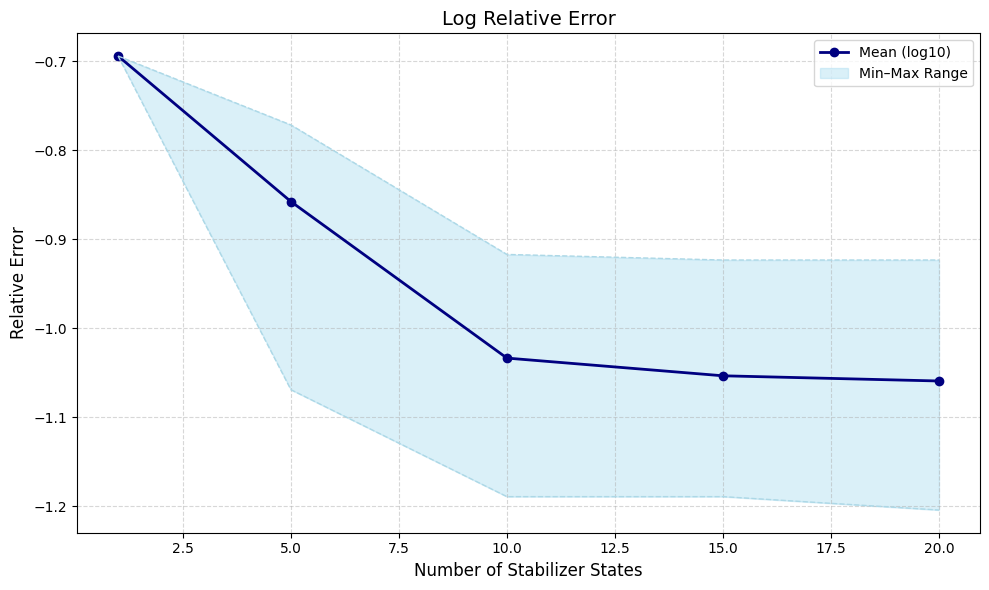

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `x` and `l_data` are already defined

# Compute mean, min, and max
mean_log = np.log10(np.mean(l_data, axis=0))
min_log = np.log10(np.min(l_data, axis=0))
max_log = np.log10(np.max(l_data, axis=0))

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, mean_log, '-o',label='Mean (log10)', color='navy', linewidth=2)
plt.fill_between(x, min_log, max_log, color='skyblue', alpha=0.3, label='Min–Max Range')
plt.plot(x, min_log, linestyle='--', color='lightblue', linewidth=1)
plt.plot(x, max_log, linestyle='--', color='lightblue', linewidth=1)

# Style and labels
plt.title('Log Relative Error', fontsize=14)
plt.xlabel('Number of Stabilizer States', fontsize=12)
plt.ylabel('Relative Error', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

In [6]:
from tqdm.notebook import tqdm
group_size_list = []

for _ in range(5):
    error = []
    group_size = []
    for n in tqdm(range(5,20)):
        coeffs, paulis = random_ising_model(n)
        H = Pauli_Hamiltonian(coeffs, paulis)    
        groups = get_excited_states(H.convert_to_spare_hamiltonian(),20)[1]
        
        group_size.append(np.min([len(t) for t in groups]))
    print(group_size)
    group_size_list.append(group_size)

  0%|          | 0/15 [00:00<?, ?it/s]

[np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


  0%|          | 0/15 [00:00<?, ?it/s]

[np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


  0%|          | 0/15 [00:00<?, ?it/s]

[np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


  0%|          | 0/15 [00:00<?, ?it/s]

[np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


  0%|          | 0/15 [00:00<?, ?it/s]

[np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


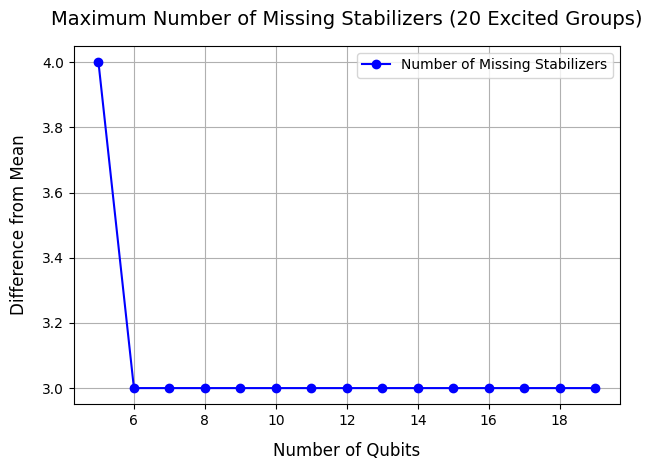

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(range(5, 20), np.array(range(5, 20)) - np.mean(group_size_list, axis=0), 
         label='Number of Missing Stabilizers', color='b', linestyle='-', marker='o')

# Customizing the plot
plt.xlabel('Number of Qubits', fontsize=12, labelpad=10)
plt.ylabel('Difference from Mean', fontsize=12, labelpad=10)  # Added a y-label for clarity
plt.title('Maximum Number of Missing Stabilizers (20 Excited Groups)', fontsize=14, pad=15)
plt.legend(fontsize=10, loc='best')

# Adding grid for better readability
plt.grid(True)

# Display the plot
plt.tight_layout()
plt.show()